# Lab №2

## Solution

### 0. Import Required Libraries 

In [82]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
import spatialmath.base as sb

### 1. Load Robot Model 


In [83]:
robot = rtb.models.DH.IRB140()

# Mass
robot.links[0].m = 28.0
robot.links[1].m = 24.0
robot.links[2].m = 9.2
robot.links[3].m = 1.68
robot.links[4].m = 0.56
robot.links[5].m = 0.18

# Center of mass
robot.links[0].r = [0, 0, 0.085]
robot.links[1].r = [-0.32, 0, 0.18]
robot.links[2].r = [-0.25, 0, 0.10]
robot.links[3].r = [0, 0.015, 0]
robot.links[4].r = [0, 0, 0]
robot.links[5].r = [0, 0, 0.035]

# Inertia tensor
robot.links[0].I = [0.20, 0.28, 0.24, 0, 0, 0]
robot.links[1].I = [0.18, 0.35, 0.33, 0, 0, 0]
robot.links[2].I = [0.052, 0.082, 0.070, 0, 0, 0]
robot.links[3].I = [0.0020, 0.0016, 0.0020, 0, 0, 0]
robot.links[4].I = [0.00035, 0.00045, 0.00035, 0, 0, 0]
robot.links[5].I = [0.00010, 0.00010, 0.000040, 0, 0, 0]

# Motor inertia
robot.links[0].Jm = 0.00045
robot.links[1].Jm = 0.00045
robot.links[2].Jm = 0.00045
robot.links[3].Jm = 0.000040
robot.links[4].Jm = 0.000040
robot.links[5].Jm = 0.000040

# Viscous friction
robot.links[0].B = 0.0018
robot.links[1].B = 0.00100
robot.links[2].B = 0.00165
robot.links[3].B = 0.000085
robot.links[4].B = 0.000100
robot.links[5].B = 0.000044

# Coulomb friction
robot.links[0].Tc = [0.48, -0.52]
robot.links[1].Tc = [0.155, -0.087]
robot.links[2].Tc = [0.160, -0.130]
robot.links[3].Tc = [0.0136, -0.0206]
robot.links[4].Tc = [0.0113, -0.0177]
robot.links[5].Tc = [0.00483, -0.0128]

# Gear ratio
robot.links[0].G = -73.5
robot.links[1].G = 127.0
robot.links[2].G = -63.0
robot.links[3].G = 89.5
robot.links[4].G = 84.5
robot.links[5].G = 90.0

# Joint limits
robot.links[0].qlim = [-2.96, 2.96]
robot.links[1].qlim = [-1.22, 2.44]
robot.links[2].qlim = [-3.73, 0.68]
robot.links[3].qlim = [-1.75, 2.95]
robot.links[4].qlim = [-1.58, 1.58]
robot.links[5].qlim = [-4.71, 4.71]


print(robot)

DHRobot: IRB 140 (by ABB), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬───────┬──────┬────────┬─────────┬────────┐
│ θⱼ  │  dⱼ   │  aⱼ  │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼───────┼──────┼────────┼─────────┼────────┤
│  q1 │ 0.352 │ 0.07 │ -90.0° │ -169.6° │ 169.6° │
│  q2 │     0 │ 0.36 │   0.0° │  -69.9° │ 139.8° │
│  q3 │     0 │    0 │ -90.0° │ -213.7° │  39.0° │
│  q4 │  0.38 │    0 │  90.0° │ -100.3° │ 169.0° │
│  q5 │     0 │    0 │ -90.0° │  -90.5° │  90.5° │
│  q6 │ 0.065 │    0 │   0.0° │ -269.9° │ 269.9° │
└─────┴───────┴──────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬──────┬───────┬─────┬──────┬──────┐
│ name │ q0  │ q1   │ q2    │ q3  │ q4   │ q5   │
├──────┼─────┼──────┼───────┼─────┼──────┼──────┤
│   qr │  0° │ -90° │  90°  │  0° │  90° │ -90° │
│   qz │  0° │  0°  │  0°   │  0° │  0°  │  0°  │
│   qd │  0° │ -90° │  180° │  0° │  0°  │ -90° │
└──────┴─────┴──────┴───────┴─────┴──────┴──────┘



### 2. Set Initial Robot Configuration and Visualize

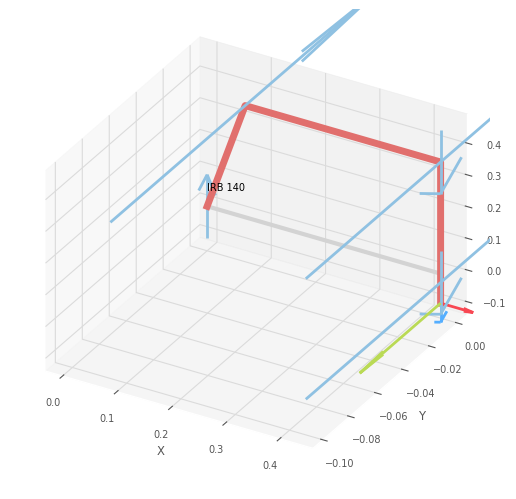

<Figure size 640x480 with 0 Axes>

In [84]:
q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

### 3. Solve Forward Kinematics

In [85]:
T_start = robot.fkine(q_start)
print(T_start)

   1         0         0         0.43      
   0        -1         0         0         
   0         0        -1        -0.093     
   0         0         0         1         



### 4. Build Manipulator Workspace

Initialize Variables

In [103]:
n = 20  # Количество точек по каждой оси
move = [np.linspace(robot.links[j].qlim[0], robot.links[j].qlim[1], n) for j in range(3)]
pose = np.zeros([3, n**3])

Calculate Workspace

In [104]:
# Проходимся перебором по каждой точке
i = 0
for q1 in move[0]:
    for q2 in move[1]:
        for q3 in move[2]:
            Tt = robot.fkine([q1,q2,q3,0,0,0])  # Решаем ПЗК, меняя только первые 3 обобщенных координаты
            for j in range(3):
                pose[j][i] = Tt.t[j]  # Сохраняем точку
            i += 1

Plot Workspace

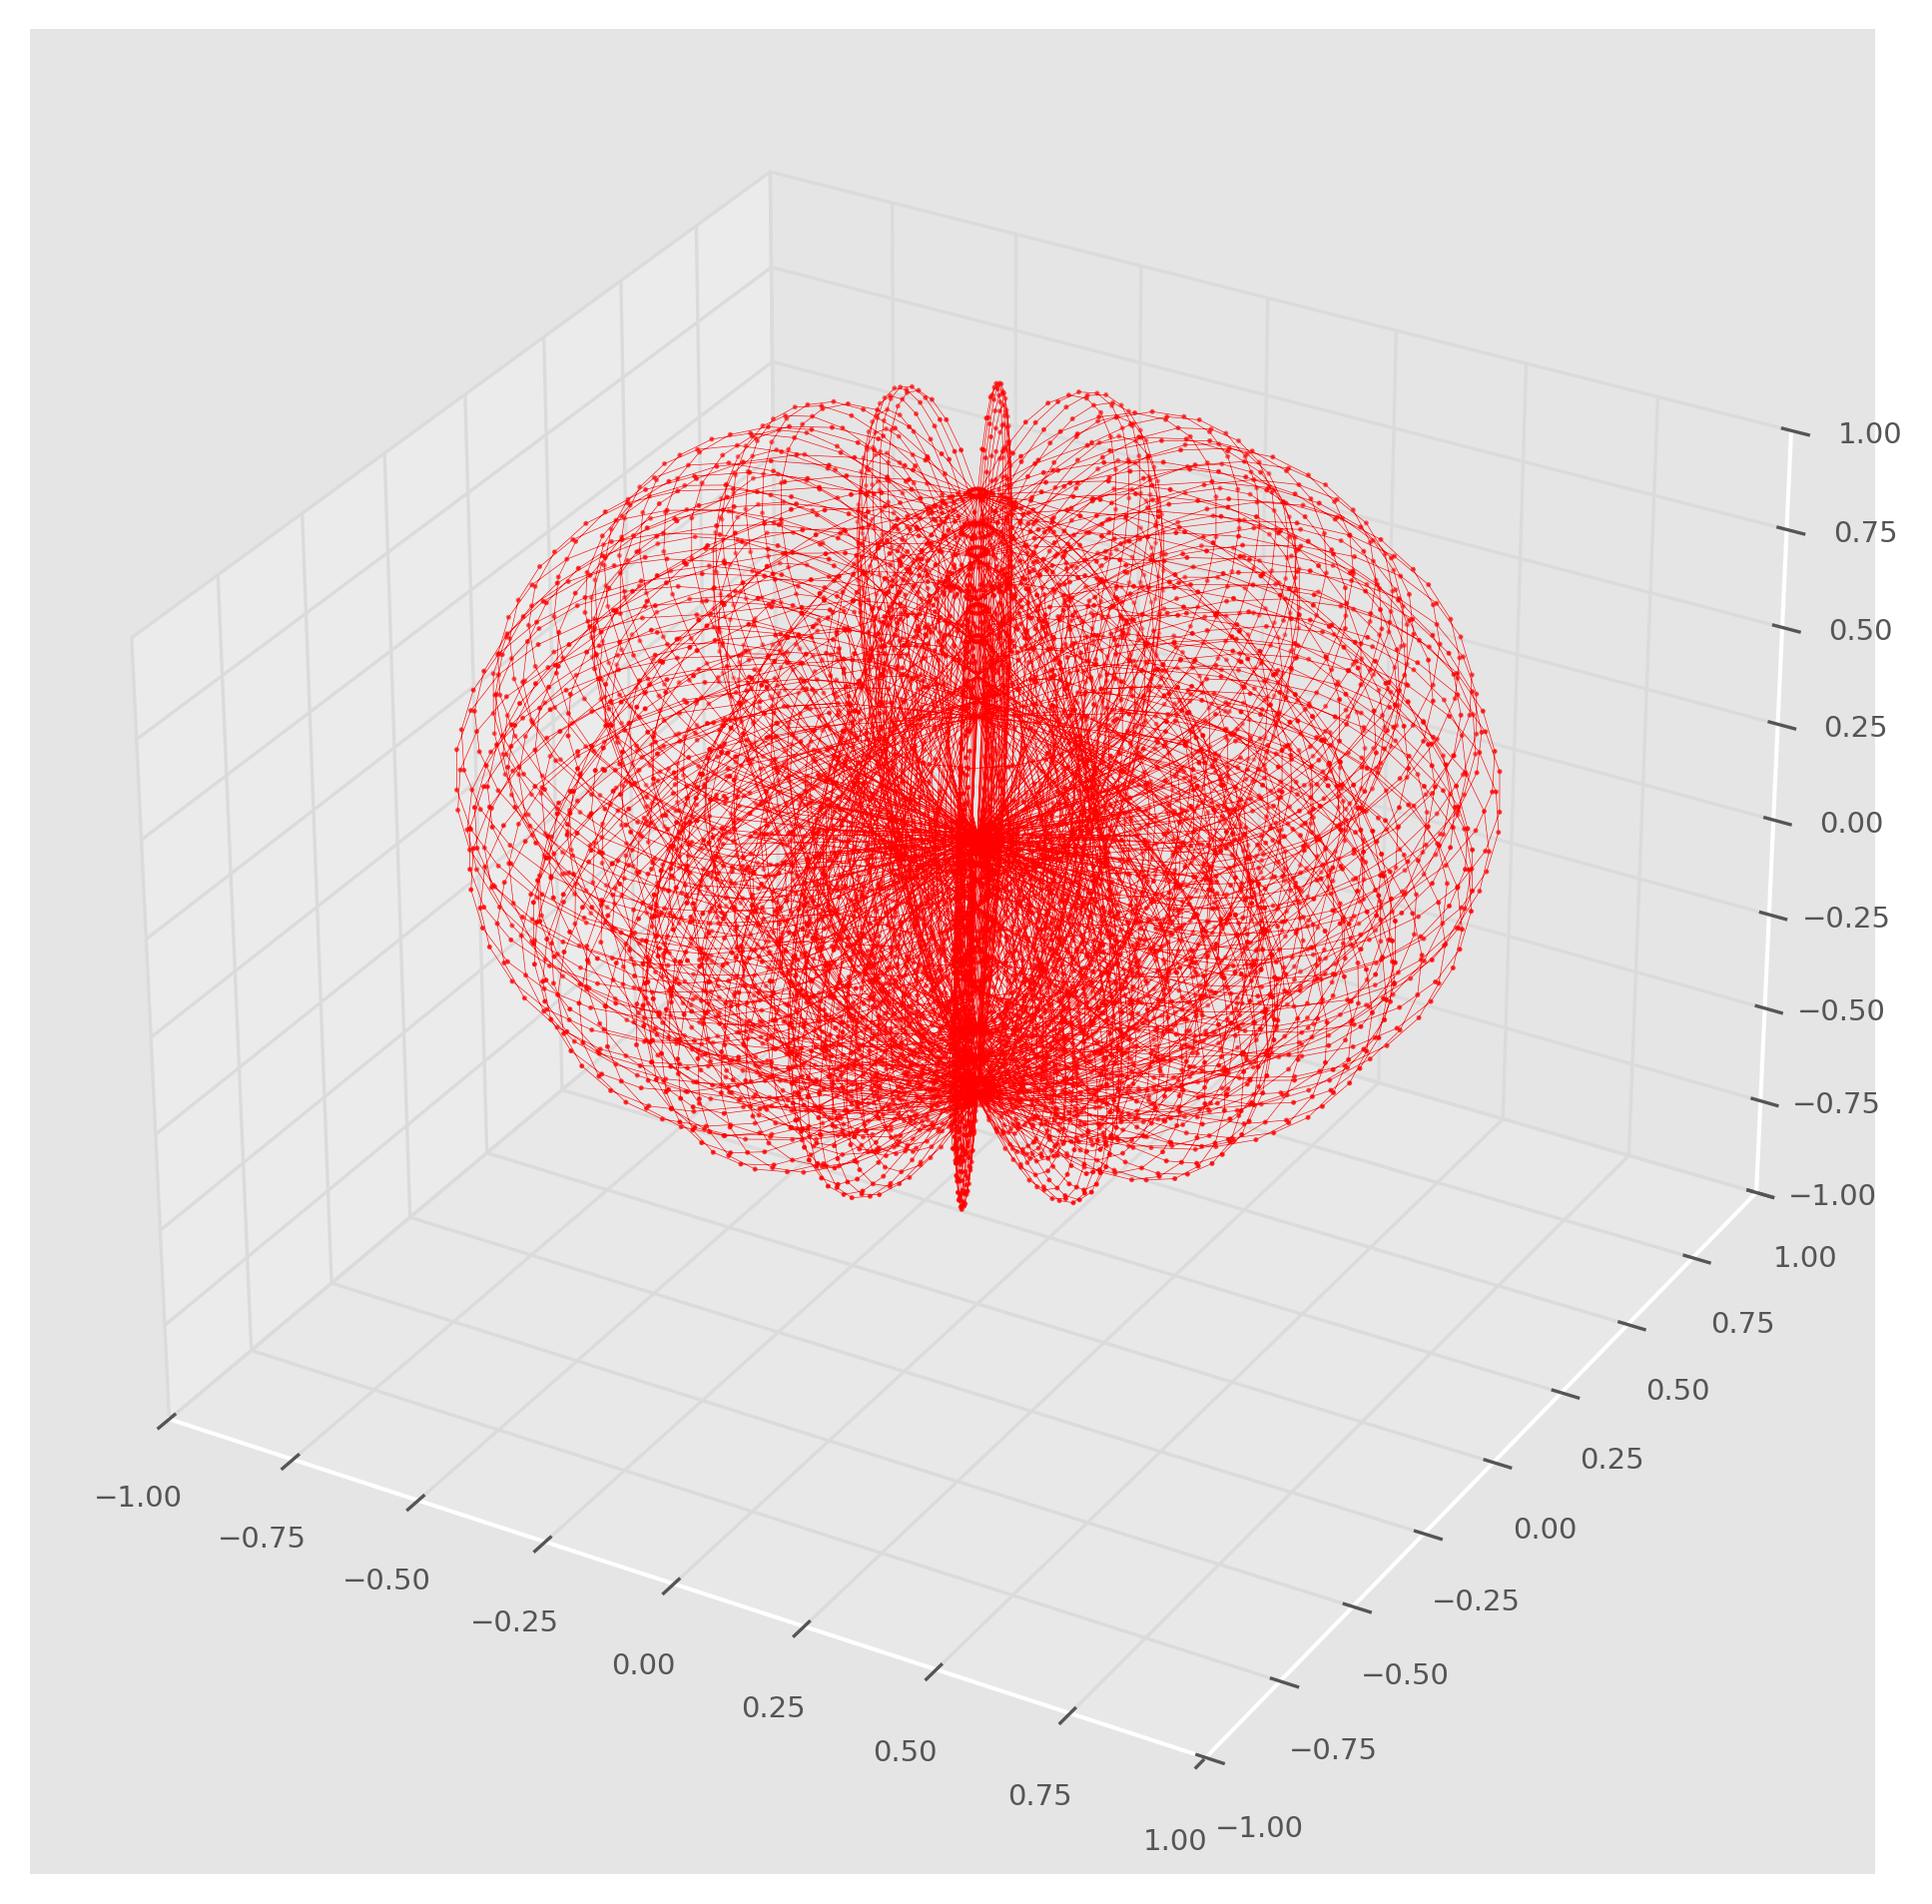

In [105]:
plt.figure(figsize=(8,8), dpi=300)
ax = plt.axes(projection="3d")
ax.plot3D(pose[0], pose[1], pose[2], color='red', linewidth=0.15)
ax.scatter3D(pose[0], pose[1], pose[2], s=0.5, color='red')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()

### 5. Select Target Point and Solve Inverse Kinematics

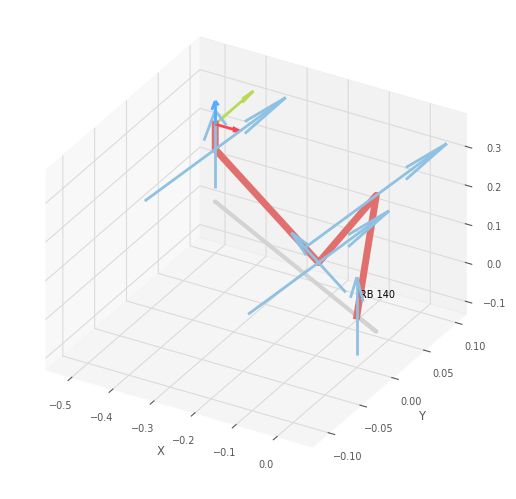

<Figure size 640x480 with 0 Axes>

In [ ]:
point = [-0.5,0.1,0.2]
T_end = sb.transl(point)
q_end = robot.ikine_GN(T_end).q  # Есть другие методы, помимо ikine_GN
robot.plot(q_end)
plt.show()

### 6. Plan Trajectory

Plan trajectory using 'jtraj' method with $N$ = 100 points

In [96]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)

tr_jtraj = rtb.jtraj(q_start, q_end, time)

Plan same trajectory using 'mtraj' method with 'trapezoidal' function

In [97]:
tr_trap = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)

Plan same trajectory using 'mtraj' method with 'quintic' function

In [98]:
tr_quin = rtb.mtraj(rtb.quintic, q_start, q_end, time)

### 7. Plot Trajectory Profiles

Plot position profiles for each joint

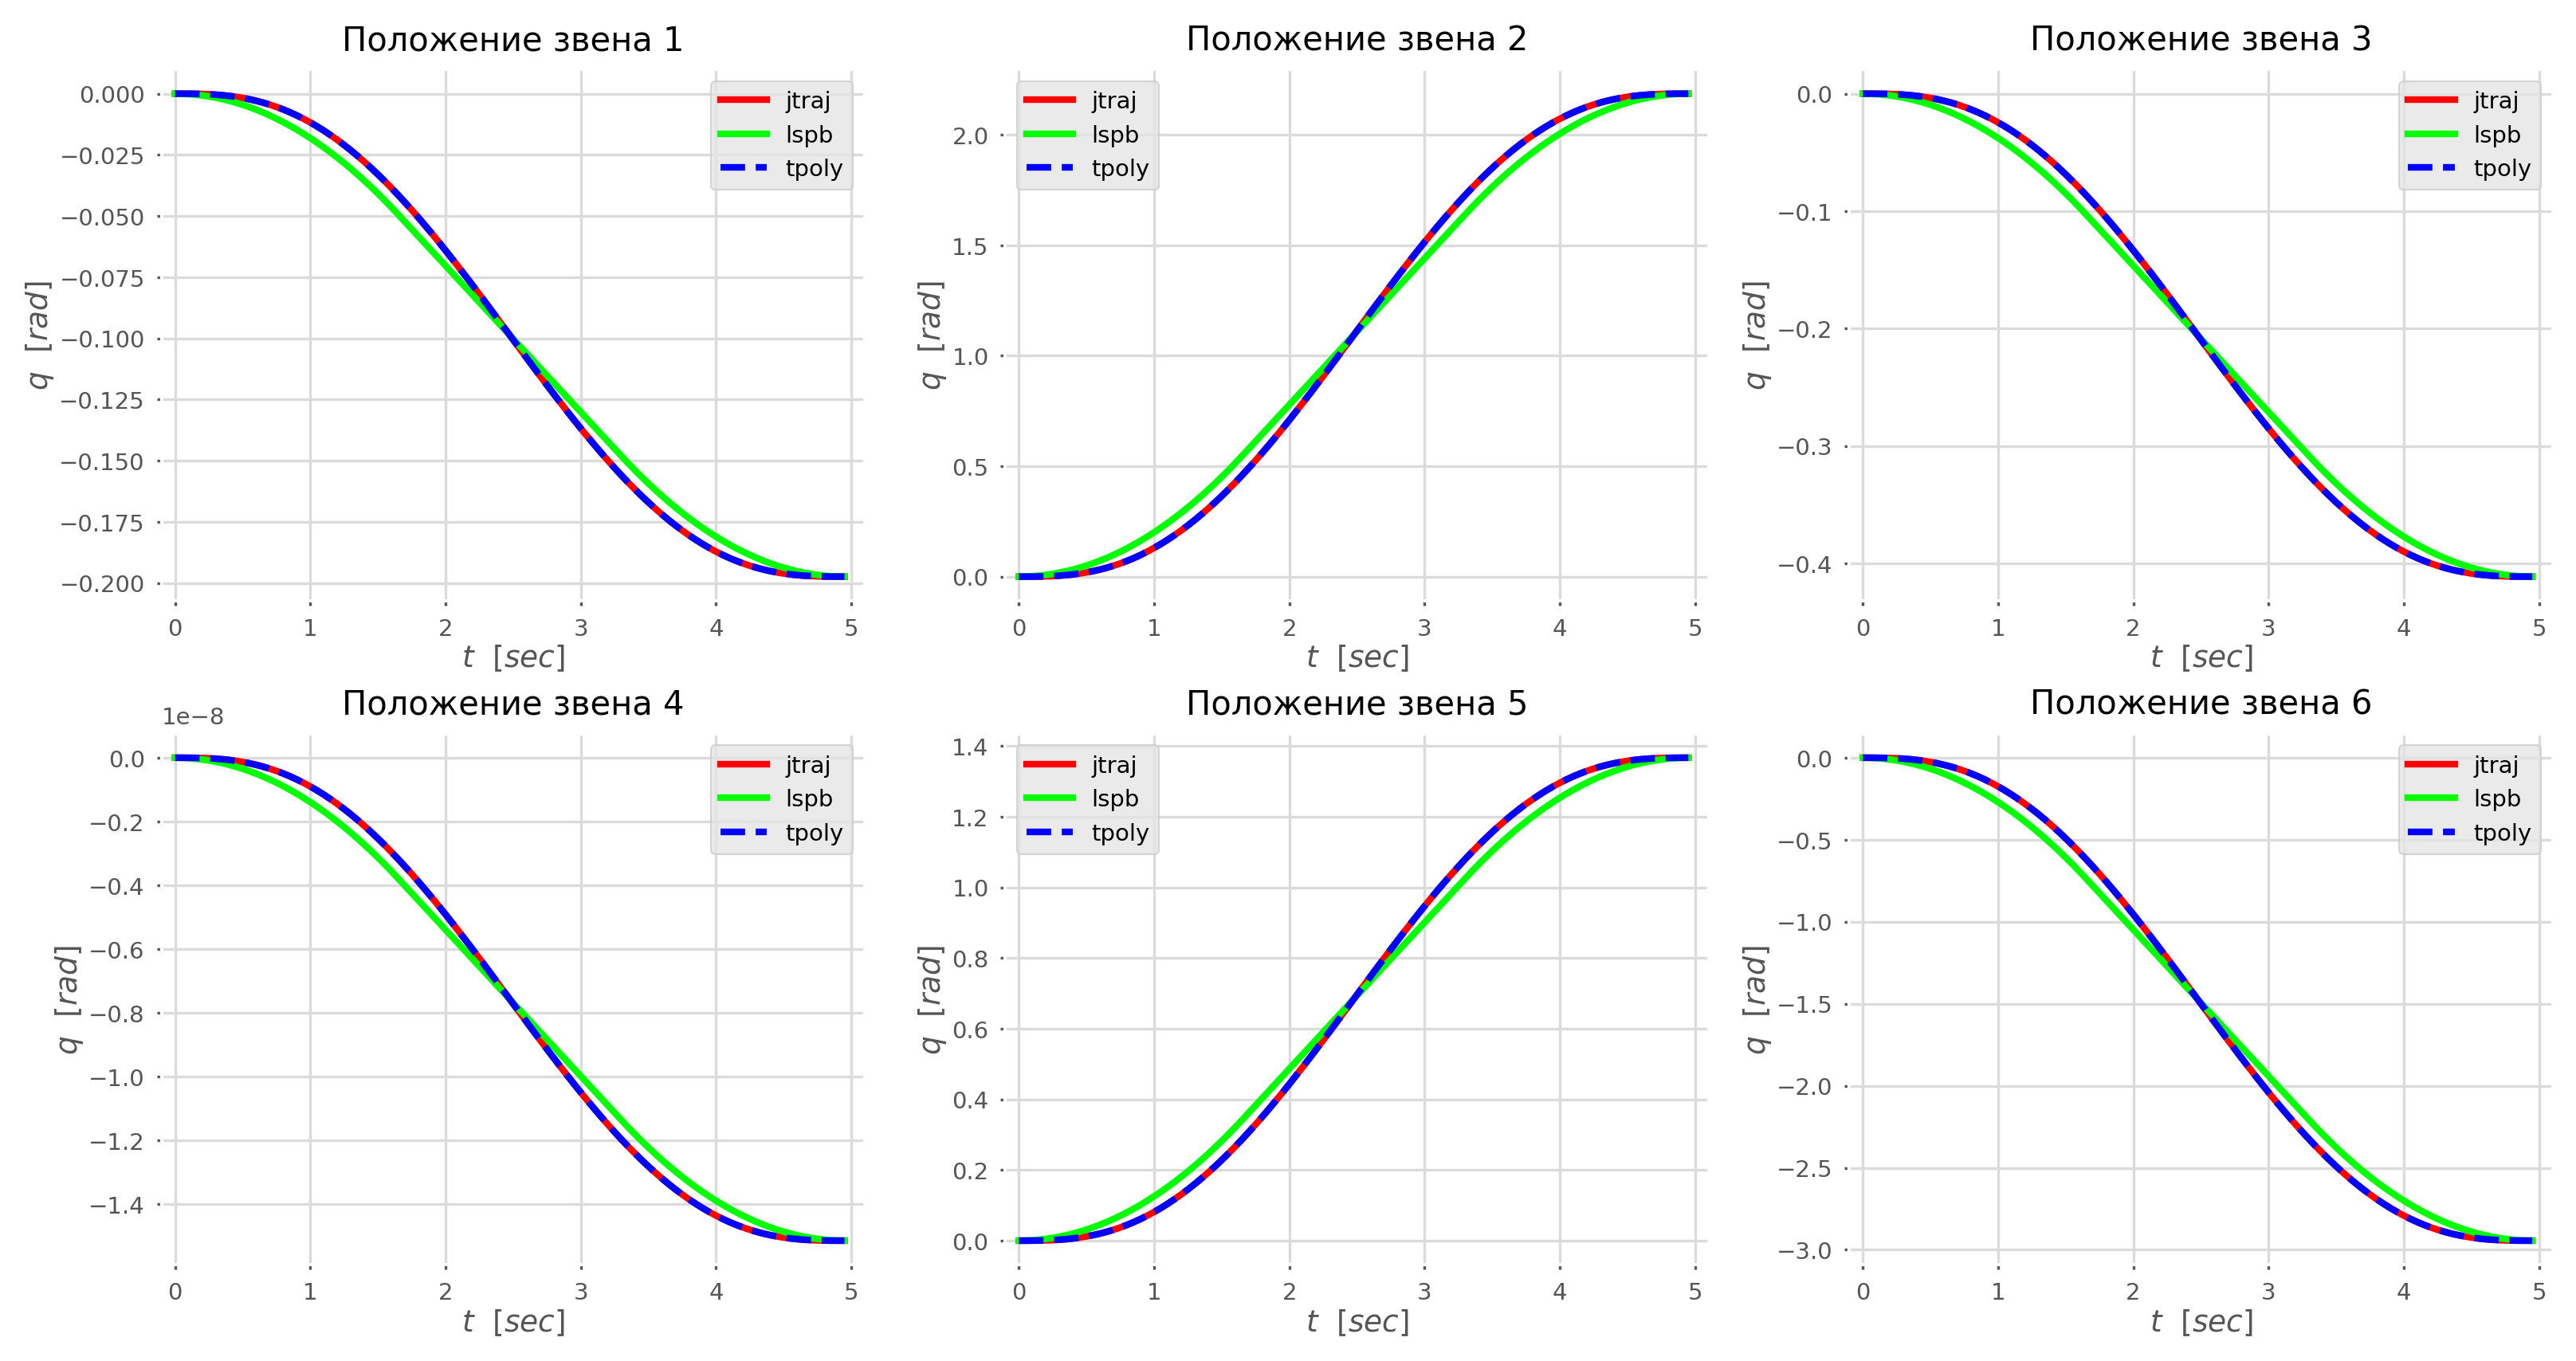

In [ ]:
plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.q[i][g-1] for i in range(len(tr_jtraj.q))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.q[i][g-1] for i in range(len(tr_trap.q))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.q[i][g-1] for i in range(len(tr_quin.q))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Положение звена {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"$q$  [$rad$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

Plot velocity profiles for each joint

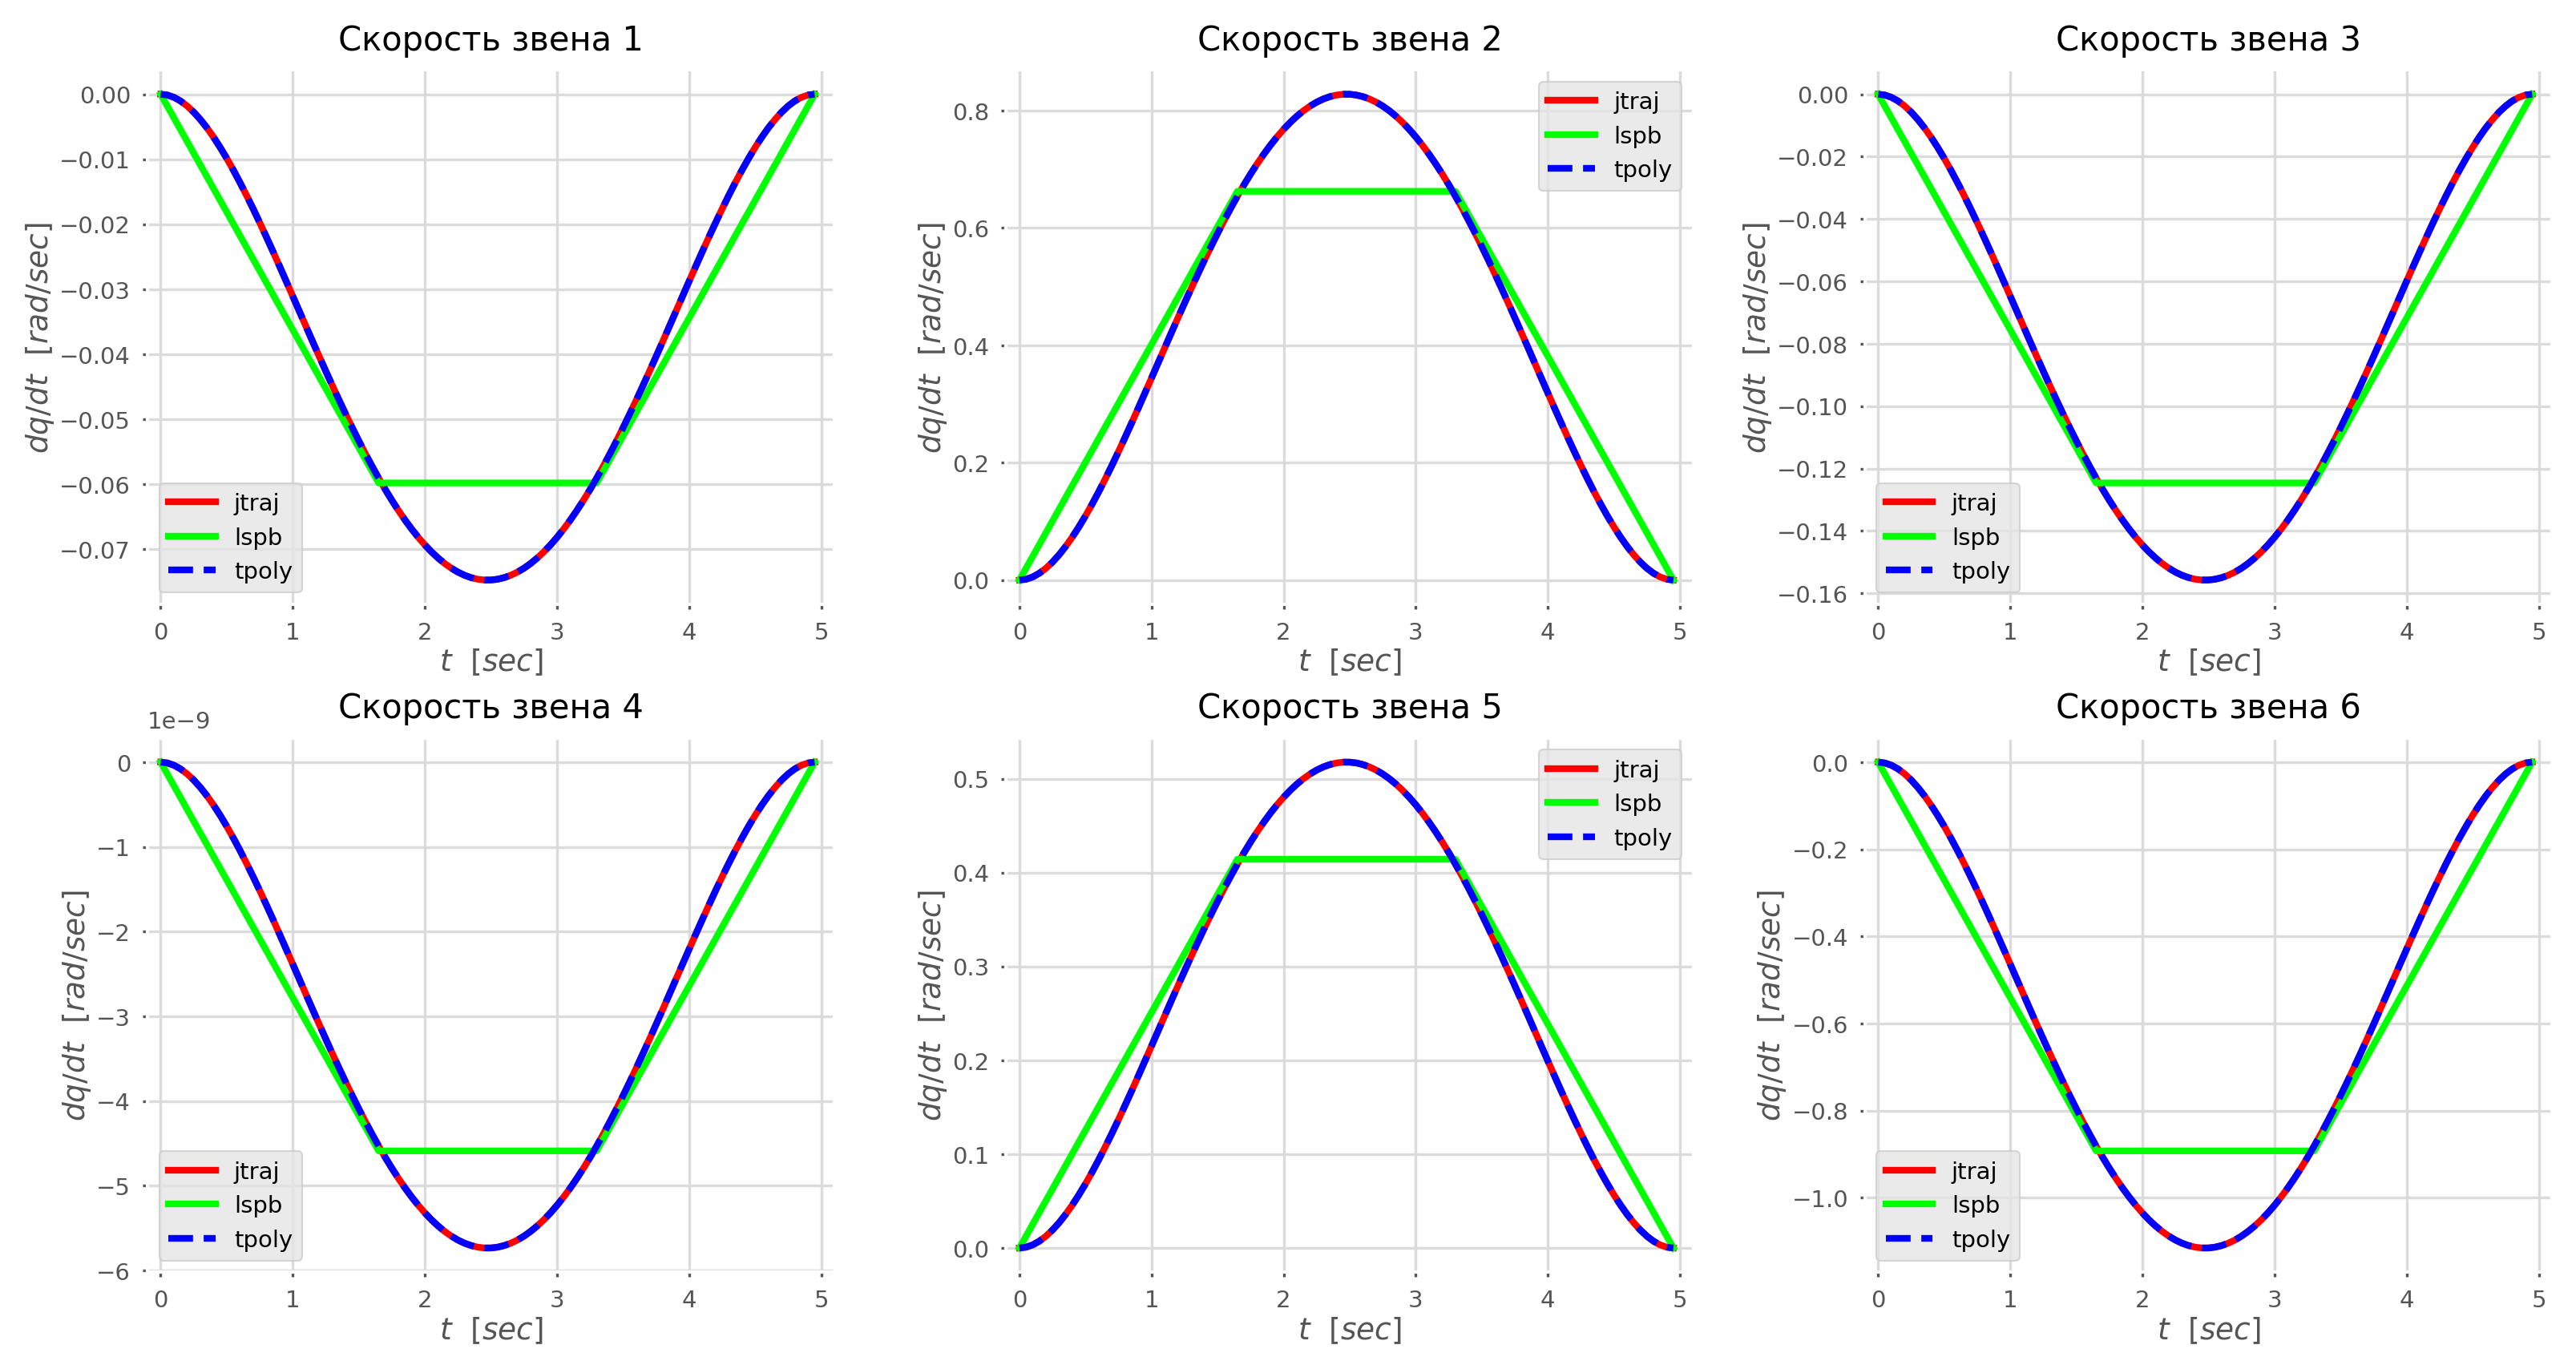

In [ ]:
plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.25, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.qd[i][g-1] for i in range(len(tr_jtraj.qd))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.qd[i][g-1] for i in range(len(tr_trap.qd))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.qd[i][g-1] for i in range(len(tr_quin.qd))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Скорость звена {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"$dq/dt$  [$rad/sec$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

Plot acceleration profiles for each joint

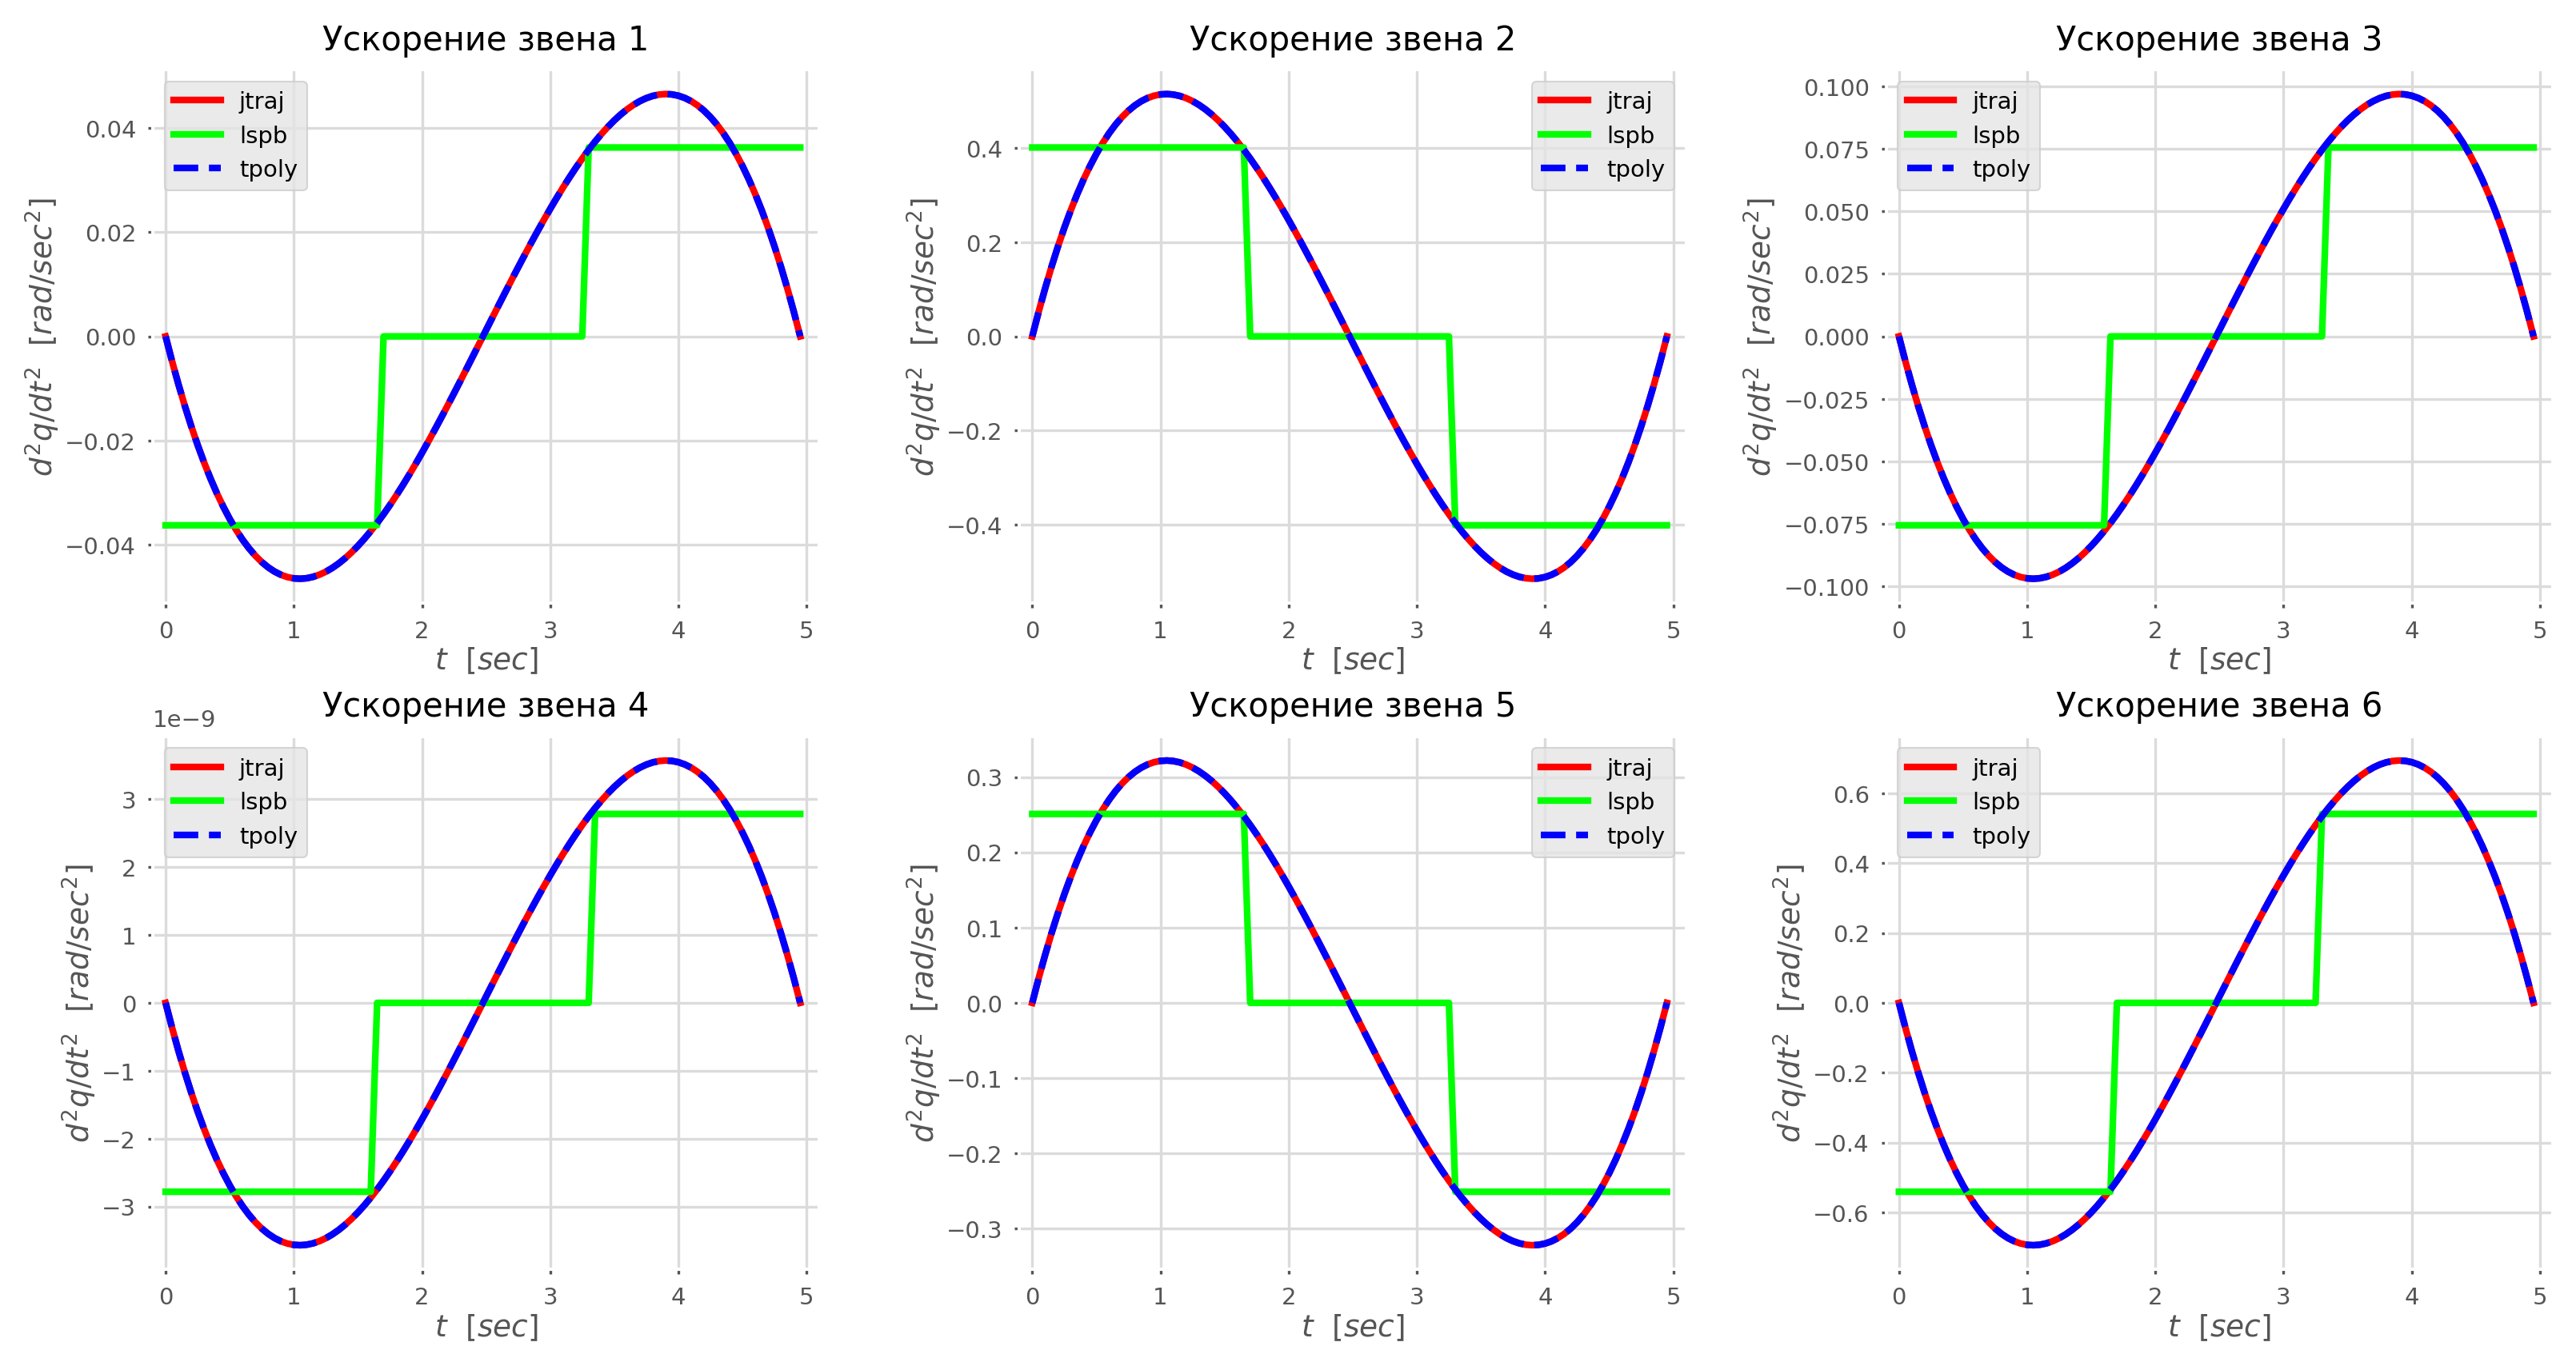

In [ ]:
fig = plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.3, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    traektoriya_jtraj = [tr_jtraj.qdd[i][g-1] for i in range(len(tr_jtraj.qdd))]  # Извлекаем нужные данные
    traektoriya_trap = [tr_trap.qdd[i][g-1] for i in range(len(tr_trap.qdd))]  # Извлекаем нужные данные
    traektoriya_quin = [tr_quin.qdd[i][g-1] for i in range(len(tr_quin.qdd))]  # Извлекаем нужные данные
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Рисуем линию
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Рисуем линию
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Рисуем линию
    plt.title(r"Ускорение звена {}".format(g), fontsize=10)  # Название графика
    plt.ylabel(r"${d^2}q/d{t^2}$  [$rad/{sec}^2$]", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

### 8. Conclusions


### CONCLUSIONS AND ANALYSIS

Based on the kinematic modeling and trajectory planning of the KUKA IRB140 manipulator, the following conclusions are drawn:

1.  **Workspace Analysis:**
    *   The generated point cloud successfully visualizes the reachable workspace of the IRB140.
    *   The workspace exhibits a roughly spherical volume with internal voids, accurately reflecting the physical joint limits defined in the Denavit-Hartenberg parameters.

2.  **Kinematic Solvers:**
    *   The forward kinematics algorithm correctly determines the end-effector pose for a given joint configuration.
    *   The Gauss-Newton numerical method (`ikine_GN`) successfully converged to a valid joint configuration for the target Cartesian point `[-0.5, 0.1, 0.2]`, proving the target is within the reachable workspace.

3.  **Trajectory Planning Comparison:**
    *   **Position ($q$):** All three methods (`jtraj`, `lspb`, `quintic`) successfully move the joints from the start to the target configuration within the designated 5-second timeframe.
    *   **Velocity ($dq/dt$):** The `lspb` (Trapezoidal) method shows a distinct constant velocity phase between acceleration and deceleration. In contrast, the polynomial methods (`jtraj` and `quintic`) exhibit smooth, bell-shaped velocity profiles.
    *   **Acceleration ($d^2q/dt^2$):** This metric highlights the primary difference between the methods. The `lspb` profile results in step-changes (discontinuities) in acceleration, which can induce mechanical jerk in real hardware. The polynomial methods (`jtraj` and `quintic`) provide continuous acceleration curves, ensuring smoother motion and reducing mechanical stress on the manipulator's joints.

4.  **Practical Implication:** 
    *   For applications prioritizing mechanical longevity and smooth operation, polynomial-based trajectories (`jtraj`/`quintic`) are superior due to their continuous acceleration profiles.